### Data Quality Analysis
Here all the missing values, duplicates, incorrect data types, inconsistent values, potential outliers, primary key uniqueness will be identified. 

In [1]:
import pandas as pd

data_path= "../data/raw/csv_files"

# reading all the csv files
customers= pd.read_csv(data_path + "/olist_customers_dataset.csv")
geolocation= pd.read_csv(data_path + "/olist_geolocation_dataset.csv")
order_items= pd.read_csv(data_path + "/olist_order_items_dataset.csv")
order_payments= pd.read_csv(data_path + "/olist_order_payments_dataset.csv")
order_reviews= pd.read_csv(data_path + "/olist_order_reviews_dataset.csv")
orders= pd.read_csv(data_path + "/olist_orders_dataset.csv")
products= pd.read_csv(data_path + "/olist_products_dataset.csv")
sellers= pd.read_csv(data_path + "/olist_sellers_dataset.csv")
category_translation= pd.read_csv(data_path + "/product_category_name_translation.csv")

In [2]:
# making a dictionary of all the files to do certain operations combinely
dfs={"customers":customers,
     "geolocation":geolocation,
     "order_items": order_items,
     "order_payments": order_payments,
     "order_reviews": order_reviews,
     "orders": orders,
     "products": products,
     "sellers": sellers,
     "category_translation": category_translation}

#### Missing values, data types, and unique value counts check

In [3]:
# Missing values, dtypes, unique value counts are identified here
# A function is created to perform these operations, instead of repeating same code for all the tables.
def column_info(df):
    # all these results are converted to a dataframe for better visibility
    info= pd.DataFrame({'dtype':df.dtypes, 'nulls':df.isnull().sum(), 'null_%':df.isnull().mean()*100, 'unique_count':df.nunique()})
    return info
# all the tables info are executed using the loop and combined using 'pd.concat' 
all_column_info= pd.concat({table_name:column_info(df) for table_name,df in dfs.items()})
all_column_info

#column_info(orders) --> if individual table's column_info wants to be checked, use this code.


dtype  nulls     null_%  \
customers            customer_id                     object      0   0.000000   
                     customer_unique_id              object      0   0.000000   
                     customer_zip_code_prefix         int64      0   0.000000   
                     customer_city                   object      0   0.000000   
                     customer_state                  object      0   0.000000   
geolocation          geolocation_zip_code_prefix      int64      0   0.000000   
                     geolocation_lat                float64      0   0.000000   
                     geolocation_lng                float64      0   0.000000   
                     geolocation_city                object      0   0.000000   
                     geolocation_state               object      0   0.000000   
order_items          order_id                        object      0   0.000000   
                     order_item_id                    int64      0   0.000000   
                     product_id                      object      0   0.000000   
                     seller_id                       object      0   0.000000   
                     shipping_limit_date             object      0   0.000000   
                     price                          float64      0   0.000000   
                     freight_value                  float64      0   0.000000   
order_payments       order_id                        object      0   0.000000   
                     payment_sequential               int64      0   0.000000   
                     payment_type                    object      0   0.000000   
                     payment_installments             int64      0   0.000000   
                     payment_value                  float64      0   0.000000   
order_reviews        review_id                       object      0   0.000000   
                     order_id                        object      0   0.000000   
                     review_score                     int64      0   0.000000   
                     review_comment_title            object  87656  88.341530   
                     review_comment_message          object  58247  58.702532   
                     review_creation_date            object      0   0.000000   
                     review_answer_timestamp         object      0   0.000000   
orders               order_id                        object      0   0.000000   
                     customer_id                     object      0   0.000000   
                     order_status                    object      0   0.000000   
                     order_purchase_timestamp        object      0   0.000000   
                     order_approved_at               object    160   0.160899   
                     order_delivered_carrier_date    object   1783   1.793023   
                     order_delivered_customer_date   object   2965   2.981668   
                     order_estimated_delivery_date   object      0   0.000000   
products             product_id                      object      0   0.000000   
                     product_category_name           object    610   1.851234   
                     product_name_lenght            float64    610   1.851234   
                     product_description_lenght     float64    610   1.851234   
                     product_photos_qty             float64    610   1.851234   
                     product_weight_g               float64      2   0.006070   
                     product_length_cm              float64      2   0.006070   
                     product_height_cm              float64      2   0.006070   
                     product_width_cm               float64      2   0.006070   
sellers              seller_id                       object      0   0.000000   
                     seller_zip_code_prefix           int64      0   0.000000   
                     seller_city                     object      0   0.000000   
    

In [4]:
# boolean indexing to check only the null columns info
all_column_info[all_column_info['nulls']>0]

dtype  nulls     null_%  \
order_reviews review_comment_title            object  87656  88.341530   
              review_comment_message          object  58247  58.702532   
orders        order_approved_at               object    160   0.160899   
              order_delivered_carrier_date    object   1783   1.793023   
              order_delivered_customer_date   object   2965   2.981668   
products      product_category_name           object    610   1.851234   
              product_name_lenght            float64    610   1.851234   
              product_description_lenght     float64    610   1.851234   
              product_photos_qty             float64    610   1.851234   
              product_weight_g               float64      2   0.006070   
              product_length_cm              float64      2   0.006070   
              product_height_cm              float64      2   0.006070   
              product_width_cm               float64      2   0.006070   

                                             unique_count  
order_reviews review_comment_title                   4527  
              review_comment_message                36159  
orders        order_approved_at                     90733  
              order_delivered_carrier_date          81018  
              order_delivered_customer_date         95664  
products      product_category_name                    73  
              product_name_lenght                      66  
              product_description_lenght             2960  
              product_photos_qty                       19  
              product_weight_g                       2204  
              product_length_cm                        99  
              product_height_cm                       102  
              product_width_cm                         95

#### Duplicates check

In [5]:
# checking for duplicates
# calculated duplicates and compared with total rows for each table and transposed for better interpretation
duplicates=pd.DataFrame({table_name:{'total_rows': len(df),'duplicate_rows': df.duplicated().sum(),
                               'duplicate_rows_%':(df.duplicated().mean()*100).round(2)
                               } for table_name,df in dfs.items()}).T
# converted the total_row and duplicate_rows columns into 'int' dtype
duplicates = duplicates.astype({"total_rows": int, "duplicate_rows": int})
duplicates

# orders.duplicated().sum() --> if duplicates want to be checked individually for each table, use this code.

,total_rows,duplicate_rows,duplicate_rows_%
customers,99441,0,0.00
geolocation,1000163,261831,26.18
order_items,112650,0,0.00
order_payments,103886,0,0.00
order_reviews,99224,0,0.00
orders,99441,0,0.00
products,32951,0,0.00
sellers,3095,0,0.00
category_translation,71,0,0.00


#### Primary key uniqueness check

In [6]:
# checking primary key uniqueness
# creating a dictionary to mention primary key for all the tables
pk_dict={'customers':'customer_id',
        'orders': 'order_id',
        'products':'product_id',
        'sellers':'seller_id',
        'category_translation':'product_category_name',
        'order_items':['order_id','order_item_id'],
        'order_payments': ['order_id','payment_sequential'],
        'order_reviews':['order_id','review_id']
        }

# primary key columns are listed along with their no. of duplicate rows 
pk_check=pd.DataFrame({table_name:{'primary_key': col_name,
                             'duplicate_keys':dfs[table_name].duplicated(subset=col_name).sum()
                             } 
                       for table_name,col_name in pk_dict.items()
                       }).T
pk_check

# orders.duplicated(subset=order_id).sum() --> if uniqueness wants to be checked for individual tables, use this code


,primary_key,duplicate_keys
customers,customer_id,0
orders,order_id,0
products,product_id,0
sellers,seller_id,0
category_translation,product_category_name,0
order_items,"[order_id, order_item_id]",0
order_payments,"[order_id, payment_sequential]",0
order_reviews,"[order_id, review_id]",0


#### Inconsistent values
There can be values inconsistent in categorical column/ numerical dolumns/ date columns. So one by one needs to be checked.

In [7]:
# checking inconsistency for categorical columns
order_payments['payment_type'].value_counts()

# 3 not defined payment_type records are observed

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [8]:
orders['order_status'].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [9]:
sellers['seller_state'].unique(), customers['customer_state'].unique()

# all state codes are consistent in two columns

(array(['SP', 'RJ', 'PE', 'PR', 'GO', 'SC', 'BA', 'DF', 'RS', 'MG', 'RN',
        'MT', 'CE', 'PB', 'AC', 'ES', 'RO', 'PI', 'MS', 'SE', 'MA', 'AM',
        'PA'], dtype=object),
 array(['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA',
        'MS', 'CE', 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB',
        'TO', 'PI', 'AC', 'SE', 'RR'], dtype=object))

In [10]:
products.columns

# product_name_length and product_description_length names are miss-spelled which needs to be corrected

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [11]:
# checking inconsistency for numerical values
num_rules = {
    'order_items: price <= 0': order_items['price'] <=0,
    'order_items: freight_value < 0': order_items['freight_value'] <0,
    'order_payments: payment_value <= 0': order_payments['payment_value'] <=0,
    'order_payments: payment_installments < 1': order_payments['payment_installments'] <1,
    'order_reviews: review_score not between 1 and 5': (order_reviews['review_score']>5) | (order_reviews['review_score']<1),
    'products: product_weight_g <= 0': products['product_weight_g']<=0,
    'products: product_length_cm <= 0' : products['product_length_cm']<=0,
    'products: product_height_cm <= 0' : products['product_height_cm']<=0,
    'products: product_width_cm <= 0' : products['product_width_cm']<=0
}

pd.Series({rule: cond.sum() for rule, cond in num_rules.items()})

# three columns have inconsistent values and all needs to be fixed.

# (order_items['price'] <= 0).sum() --> use this code if individual inconsistency in numerical values needs to be checked.

order_items: price <= 0                            0
order_items: freight_value < 0                     0
order_payments: payment_value <= 0                 9
order_payments: payment_installments < 1           2
order_reviews: review_score not between 1 and 5    0
products: product_weight_g <= 0                    4
products: product_length_cm <= 0                   0
products: product_height_cm <= 0                   0
products: product_width_cm <= 0                    0
dtype: int64

In [12]:
# checking inconsistency in date columns
# In order to perform operations, these date columns needs to be converted to datetime format.
# Since it is not done yet, a copy of orders table will be created.
orders_date_cols=['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
                   'order_delivered_customer_date','order_estimated_delivery_date']
orders_dt= orders.copy()
orders_dt[orders_date_cols]=orders_dt[orders_date_cols].apply(pd.to_datetime)

# rules are created using dictionary for inconsistent date logics
date_rules= { 'orders: approved_date< purchased_date': 
             orders_dt['order_approved_at']<orders_dt['order_purchase_timestamp'],
             'orders: carrier_delivered_date < purchased_date': 
             orders_dt['order_delivered_carrier_date']< orders_dt['order_purchase_timestamp'],
             'orders: customer_delivered_date < purchased_date': 
             orders_dt['order_delivered_customer_date']< orders_dt['order_purchase_timestamp'],
             'orders: customer_delivered_date < carrier_delivered_date':
             orders_dt['order_delivered_customer_date']<orders_dt['order_delivered_carrier_date'],
             'orders: status["canceled"] and customer_delivered_date not null':
             (orders_dt['order_status']=='canceled') & (orders_dt['order_delivered_customer_date'].notnull()),
             'orders: status["delivered"] and customer_delivered_date is null':
             (orders_dt['order_status']=='delivered') & (orders_dt['order_delivered_customer_date'].isnull())
             }
pd.Series({rule: cond.sum() for rule,cond in date_rules.items()})

# carrier_delivered_date has more inconsistent date which can be seen from two of the results. So it may not be reliable.

orders: approved_date< purchased_date                                0
orders: carrier_delivered_date < purchased_date                    166
orders: customer_delivered_date < purchased_date                     0
orders: customer_delivered_date < carrier_delivered_date            23
orders: status["canceled"] and customer_delivered_date not null      6
orders: status["delivered"] and customer_delivered_date is null      8
dtype: int64

In [13]:
# checking the range of dates in which orders made
orders_dt["order_purchase_timestamp"].agg(["min", "max"])

min   2016-09-04 21:15:19
max   2018-10-17 17:30:18
Name: order_purchase_timestamp, dtype: datetime64[ns]

In [14]:
# checking the month and year wise order counts which will be helpful during the analyzing of year_month wise trend
orders_dt["order_purchase_timestamp"].dt.to_period("M").value_counts().sort_index()

# first few months and last few months have less orders

order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

#### Outliers detection

In [15]:
# checking outliers using describe
order_items[['price','freight_value']].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [16]:
order_payments[['payment_value','payment_installments']].describe()

,payment_value,payment_installments
count,103886.000000,103886.000000
mean,154.100380,2.853349
std,217.494064,2.687051
min,0.000000,0.000000
25%,56.790000,1.000000
50%,100.000000,1.000000
75%,171.837500,4.000000
max,13664.080000,24.000000


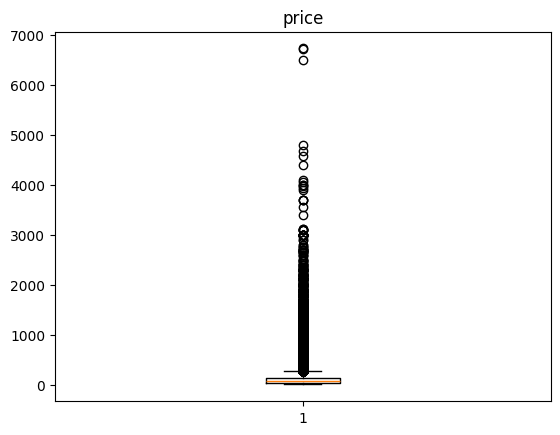

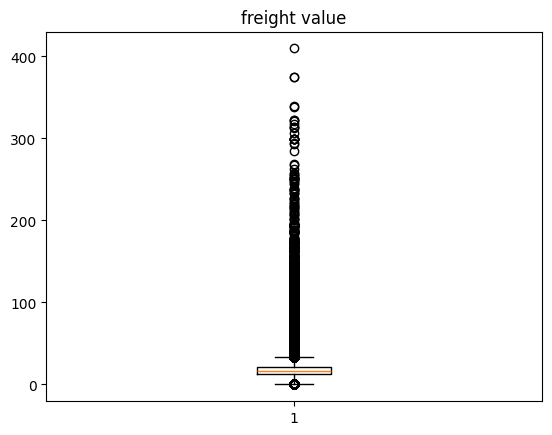

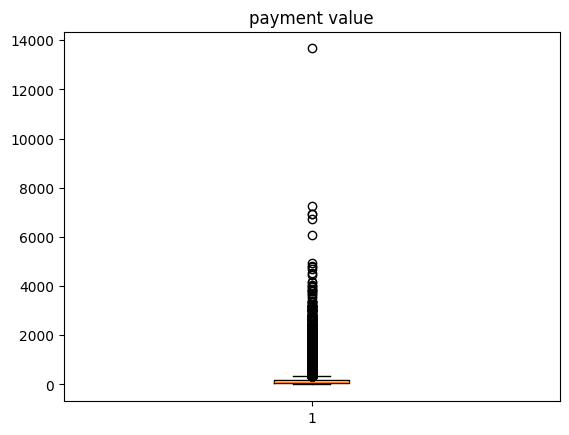

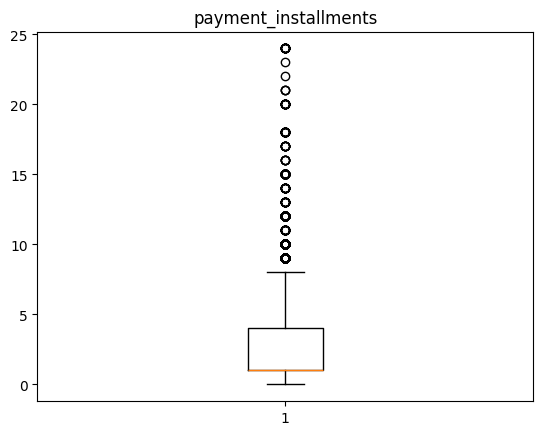

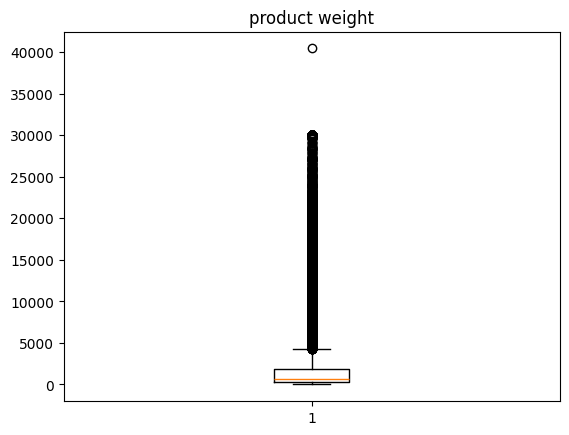

In [17]:
# Creating a dictionary to check outliers for those columns mentioned in it.
import matplotlib.pyplot as plt
outliers_dict={
    'price':order_items['price'],
    'freight value': order_items['freight_value'],
    'payment value': order_payments['payment_value'],
    'payment_installments':order_payments['payment_installments'],
    'product weight': products['product_weight_g']
}
for name,col in outliers_dict.items():
    plt.boxplot(col.dropna())
    plt.title(name)
    plt.show()

    # these many outliers does not mean all these are invalid. Eg: For price most of the orders are low prices (right_skewed data).

### **Observations**
1. Missing values: Out of 9 tables in the dataset, only 3 tables (orders, products, order_reviews) have nulls in which all columns except product_id having nulls from products table. The null from orders tables in date columns are expected as these orders may be cancelled or still not delivered. 
2. Incorrect data types: All the date columns are shown as object dtype instead of datetime dtype. They need to be changed to datetime dtype. Also the zip code prefix are in int dtype. As they are identifiers they need to be changed to str dtype.
3. Duplicates: Only geolocation contains duplicates and they need to be removed.
4. All rows have primary key uniqueness.
5. 3 not defined payment_type records are observed.
6. product_name_length and product_description_length names are miss-spelled which needs to be corrected.
7. 3 numeric columns (payment_value, payment_installments, product_weight) have inconsistent values and all needs to be fixed.
8. Carrier_delivered_date have some inconsitent values which needs to be checked.
9. 2 other rules from date_inconsistency rules alos need to be investigated.
10. First few months and last few months have less orders purchased.
11. Many outliers present in the data does not mean all these are invalid. 
12. Eg: For price, most of the orders are low prices (right_skewed data). But the high price orders are valid too.